In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.VIM import ViMTorchConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")


In [3]:
from experiment_notebooks.comparision_search.dataset_prep_mnist import create_data
dataset = "mnist"
batch_size = 64
dataset_dict = create_data(experiment_files_path_data, batch_size=batch_size, dataset=dataset)
dataset_train = dataset_dict["dataset_train"]
dataset_val = dataset_dict["dataset_val"]
dataset_test = dataset_dict["dataset_test"]
train_loader = dataset_dict["train_loader"]
val_loader = dataset_dict["val_loader"]
test_loader = dataset_dict["test_loader"]
val_loader_transformed = dataset_dict["val_loader_transformed"]
n_classes = dataset_dict["n_classes"]



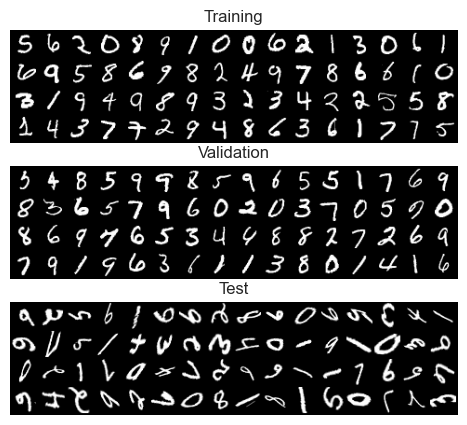

In [4]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [5]:
from experiment_notebooks.comparision_search.dataset_prep_mnist import load_model_mnist

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_model4.pth")
model = load_model_mnist(modelpath, train_loader,val_loader)

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_search\model\mnist_model4.pth


In [6]:
with torch.no_grad():
    model.eval().cuda()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9924.


In [7]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.395.


In [30]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
for batch in train_loader:
    emb,_ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())

embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 500000:
    indices = np.random.choice(embeddings.shape[0], 500000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes


In [9]:
torch.cuda.empty_cache()

In [10]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.control.split import SplitConfidence

from confidence.direct.logit_based import EnergyConfidence

In [11]:
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION.value, AffineTransformation2D.SHEARING_X.value,
                       AffineTransformation2D.SHEARING_Y.value
        , AffineTransformation2D.SCALING_X.value, AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi, torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1 / 1.3 - 1, 0.3),), ((1 / 1.3 - 1, 0.3),)]

In [12]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [13]:
domains

[(-3.141592653589793, 3.141592653589793),
 ((-0.5, 0.5),),
 ((-0.5, 0.5),),
 ((-0.23076923076923084, 0.3),),
 ((-0.23076923076923084, 0.3),)]

In [14]:
#reprint domain but without deep nesting
domains2 = [(-torch.pi, torch.pi), (-0.5, 0.5), (-0.5, 0.5), (1 / 1.3 - 1, 0.3), (1 / 1.3 - 1, 0.3)]

In [15]:
#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence
transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)





In [16]:
di = search.shgo.SHGO(selection_method="topk", initial_samples=100, local_runs=2, local_max_steps=5)
di_no_grad = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [17]:
class ITSWRAPPER(nn.Module):
    def __init__(self, its):
        super(ITSWRAPPER, self).__init__()
        self.its = its

    def optimize(self, problem, data):
        # Use the ITS to infer the transformation
        self.its.confidence_module = problem.confidence_module
        data_canonic, logits = self.its.infer(data)
        # Return the parameters of the transformation
        return data_canonic,logits

In [18]:
conf_energy = SinglePassConfidence(model, EnergyConfidence())
transformation_problem_energy = TransformationProblem(conf_energy,transform_seq)

In [19]:
nn_pytorch = KNNConfidence(metric="cosine")
nn_pytorch.fit(embeddings)
nn_pytorch.cuda()

conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

In [20]:
from confidence.input_transform import PCAInputModule,InputTransformImage
#input_module = PCAInputModule(n_components= 1024,keep_first=True)
input_module = InputTransformImage(reduce_dims=(3,3))

In [21]:
from tqdm import tqdm
import time

def optimize_and_test(problem, optimizer, name):
    problem.max_batch_size = 128 * 4
    start_time = time.time()
    test_acc_sim = 0
    counter = 0

    pbar = tqdm(test_loader, desc=f"Testing {name}")
    for data, target in pbar:
        data, target = data.cuda(), target.cuda()
        res = optimizer.optimize(problem, data)

        if isinstance(optimizer, ITSWRAPPER):
            x_transformed2, _ = res
            x_transformed2 = x_transformed2.squeeze(1)
        else:
            x_transformed2 = problem.transform(data, res[0])

        logits = model(x_transformed2)
        output = logits.argmax(dim=-1)
        test_acc_sim += output.eq(target).sum().item()
        counter += output.size(0)

        # update tqdm with intermediate accuracy
        current_acc = test_acc_sim / counter
        pbar.set_postfix(mean_acc=f"{current_acc:.4f}")

    final_acc = test_acc_sim / counter
    elapsed = time.time() - start_time
    print(f"Mean accuracy on the transformed test set with {name}: {final_acc:.4f}.")
    print(f"Time taken: {elapsed:.2f} seconds")

import search.tree
import importlib
importlib.reload(search.tree)
from search.tree import CoordinateDescent



In [22]:
import search.evo
import importlib
importlib.reload(search.evo)
from search.evo import EvolutionarySearch

sev = EvolutionarySearch(population_size=30,num_iters=4,selection_frac=1.0)
optimize_and_test(transformation_problem_energy, sev,"Nlopt sev")

Testing Nlopt sev: 100%|██████████| 79/79 [00:05<00:00, 15.67it/s, mean_acc=0.8044]

Mean accuracy on the transformed test set with Nlopt sev: 0.8044.
Time taken: 5.04 seconds


In [23]:
from its.search import InverseTransformationSearch

In [24]:
its = InverseTransformationSearch(model, transformation=transformations, domain=domains2,
                                  n_samples=24, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='off', en_unique_class_condition=True,gaussian_filter_channel_wise=False,confidence_module=SinglePassConfidence(model, EnergyConfidence()))


In [25]:

from time import sleep

with torch.no_grad():
    model.eval()
    #sleep 1
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')


Mean accuracy on the transformed test set [but with ITS]: 0.8068.


In [26]:
from search.shgo import SHGO
random_search = SHGO(selection_method="topk", initial_samples=240, local_runs=1, local_max_steps=1)
optimize_and_test(transformation_problem_energy, random_search,"Random Search NN Pytorch")

Testing Random Search NN Pytorch: 100%|██████████| 79/79 [00:06<00:00, 12.82it/s, mean_acc=0.8228]

Mean accuracy on the transformed test set with Random Search NN Pytorch: 0.8228.
Time taken: 6.16 seconds


In [31]:
nn_pytorch = KNNConfidence(metric="cosine")
nn_pytorch.fit(embeddings_sampled)
nn_pytorch.cuda()

conf_split = SplitConfidence(nn_pytorch, EnergyConfidence(), mult=False, b=0.0000)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.936.


In [32]:
optimize_and_test(problem_nn_pytorch, random_search,"Random Search NN Pytorch")


Testing Random Search NN Pytorch: 100%|██████████| 79/79 [00:09<00:00,  8.14it/s, mean_acc=0.9390]

Mean accuracy on the transformed test set with Random Search NN Pytorch: 0.9390.
Time taken: 9.70 seconds


In [29]:
dfgfdsg

NameError: name 'dfgfdsg' is not defined

In [28]:
transform_seq.init_method ="uniform"

In [29]:
from search.shgo import SHGO
from search.simulated_anealing import ParallelSimulatedAnnealing
from search.evo import EvolutionarySearch
from search.parallel_gradient import ParallelGradientDescent,WindowStuckDetectionDescent,PointNoiseParallelDescent,ParallelRestartingDescent


In [30]:
sim = ParallelSimulatedAnnealing(initial_temp=0,max_iterations=6,parallel_runs=20)

In [31]:
evo = EvolutionarySearch(population_size=30,num_iters=4,selection_frac=1.0)

In [32]:
pd = ParallelGradientDescent(max_iterations=6, parallel_runs=10)
pd_long = ParallelGradientDescent(max_iterations=15, parallel_runs=4)

In [33]:
wpd = WindowStuckDetectionDescent(max_iterations=6, parallel_runs=10, stuck_window_size=3)
wpd_long = WindowStuckDetectionDescent(max_iterations=15, parallel_runs=4, stuck_window_size=3)

In [34]:
pnpd = PointNoiseParallelDescent(max_iterations=6, parallel_runs=10, noise_scale=0.3)
pnpd_long = PointNoiseParallelDescent(max_iterations=15, parallel_runs=4, noise_scale=0.3)

In [35]:
random_search = SHGO(selection_method="topk", initial_samples=108, local_runs=4, local_max_steps=3)

In [36]:
random_search_long = SHGO(selection_method="topk", initial_samples=80, local_runs=4, local_max_steps=10)

In [37]:
near_ground_truth = SHGO(selection_method="topk", initial_samples=2000,local_runs=1,local_max_steps=0)


In [38]:
prgd = ParallelRestartingDescent(max_iterations=6, parallel_runs=10, reinit_interval=1,reinit_amount=5)
prgd_long = ParallelRestartingDescent(max_iterations=15, parallel_runs=4, reinit_interval=2,reinit_amount=2)

In [39]:
its_wrapper = ITSWRAPPER(its).cuda()

In [40]:
transformation_problem_energy.max_batch_size = 12800
problem_nn_pytorch.max_batch_size = 3200

In [41]:
optims= [
    (near_ground_truth, "Near Ground Truth Search"),
    (sim, "Parallel Simulated Annealing"),
    (evo, "Evolutionary Algorithm"),
    (pd, "Parallel Gradient Descent"),
    (pd_long, "Parallel Gradient Descent Long"),
    (wpd, "Window Stuck Detection Descent"),
    (wpd_long, "Window Stuck Detection Descent Long"),
    (pnpd, "Point Noise Parallel Descent"),
    (pnpd_long, "Point Noise Parallel Descent Long"),
    (random_search, "Random Search"),
    (random_search_long, "Random Search Long"),
    (prgd, "Parallel Restarting Gradient Descent"),
    (prgd_long, "Parallel Restarting Gradient Descent Long"),
    (its_wrapper, "ITS"),

]

In [42]:
torch.cuda.empty_cache()

In [43]:
for optimizer, name in optims:
    print(f"Testing {name}...")
    optimize_and_test(transformation_problem_energy, optimizer,name)

Testing Near Ground Truth Search...


Testing Near Ground Truth Search: 100%|██████████| 79/79 [00:44<00:00,  1.77it/s, mean_acc=0.8124]


Mean accuracy on the transformed test set with Near Ground Truth Search: 0.8124.
Time taken: 44.67 seconds
Testing Parallel Simulated Annealing...


Testing Parallel Simulated Annealing: 100%|██████████| 79/79 [00:04<00:00, 17.36it/s, mean_acc=0.7368]


Mean accuracy on the transformed test set with Parallel Simulated Annealing: 0.7368.
Time taken: 4.55 seconds
Testing Evolutionary Algorithm...


...

Mean accuracy on the transformed test set with Parallel Restarting Gradient Descent: 0.7676.
Time taken: 11.09 seconds
Testing Parallel Restarting Gradient Descent Long...


Testing Parallel Restarting Gradient Descent Long: 100%|██████████| 79/79 [00:13<00:00,  5.75it/s, mean_acc=0.7244]


Mean accuracy on the transformed test set with Parallel Restarting Gradient Descent Long: 0.7244.
Time taken: 13.75 seconds
Testing ITS...


Testing ITS: 100%|██████████| 79/79 [00:03<00:00, 22.07it/s, mean_acc=0.8018]

Mean accuracy on the transformed test set with ITS: 0.8018.
Time taken: 3.58 seconds


In [44]:
for optimizer, name in optims:
    print(f"Testing {name}...")
    optimize_and_test(problem_nn_pytorch, optimizer,name)

Testing Near Ground Truth Search...


Testing Near Ground Truth Search: 100%|██████████| 79/79 [00:49<00:00,  1.58it/s, mean_acc=0.9338]


Mean accuracy on the transformed test set with Near Ground Truth Search: 0.9338.
Time taken: 49.94 seconds
Testing Parallel Simulated Annealing...


Testing Parallel Simulated Annealing: 100%|██████████| 79/79 [00:05<00:00, 14.92it/s, mean_acc=0.8224]


Mean accuracy on the transformed test set with Parallel Simulated Annealing: 0.8224.
Time taken: 5.30 seconds
Testing Evolutionary Algorithm...


...

Mean accuracy on the transformed test set with Parallel Restarting Gradient Descent: 0.8816.
Time taken: 11.65 seconds
Testing Parallel Restarting Gradient Descent Long...


Testing Parallel Restarting Gradient Descent Long: 100%|██████████| 79/79 [00:15<00:00,  5.02it/s, mean_acc=0.8316]


Mean accuracy on the transformed test set with Parallel Restarting Gradient Descent Long: 0.8316.
Time taken: 15.73 seconds
Testing ITS...


Testing ITS: 100%|██████████| 79/79 [00:03<00:00, 19.84it/s, mean_acc=0.8908]

Mean accuracy on the transformed test set with ITS: 0.8908.
Time taken: 3.98 seconds
